<a href="https://colab.research.google.com/github/OmarFarukNoman/Into-to-Machine-Learning/blob/main/Homework-7/Problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem-1(a)**

Device: cuda

Epoch=1 
Training Loss: 1.5069, Training Accuracy: 0.4653
Validation Loss: 1.2723, Validation Accuracy: 0.5440

Epoch=2 
Training Loss: 1.1841, Training Accuracy: 0.5810
Validation Loss: 1.1487, Validation Accuracy: 0.5894

Epoch=3 
Training Loss: 1.0850, Training Accuracy: 0.6165
Validation Loss: 1.0933, Validation Accuracy: 0.6138

Epoch=4 
Training Loss: 1.0248, Training Accuracy: 0.6378
Validation Loss: 1.1207, Validation Accuracy: 0.6076

Epoch=5 
Training Loss: 0.9868, Training Accuracy: 0.6510
Validation Loss: 1.0679, Validation Accuracy: 0.6207

Epoch=6 
Training Loss: 0.9555, Training Accuracy: 0.6633
Validation Loss: 1.0724, Validation Accuracy: 0.6231

Epoch=7 
Training Loss: 0.9277, Training Accuracy: 0.6751
Validation Loss: 1.0374, Validation Accuracy: 0.6412

Epoch=8 
Training Loss: 0.9079, Training Accuracy: 0.6813
Validation Loss: 1.0324, Validation Accuracy: 0.6393

Epoch=9 
Training Loss: 0.8899, Training Accuracy: 0.6881
Validation Loss: 1.0602, Validat

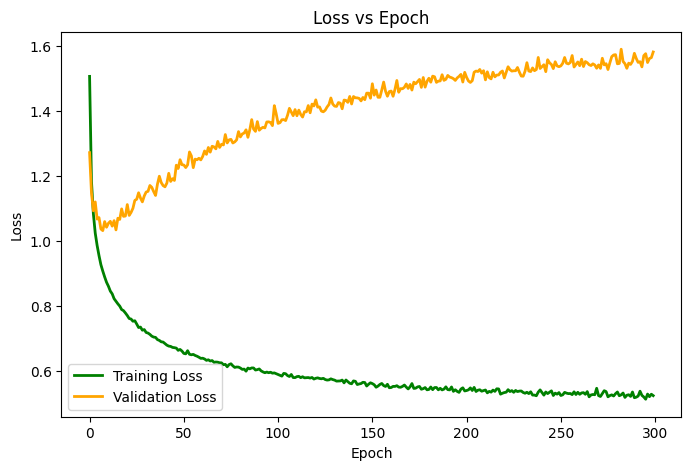

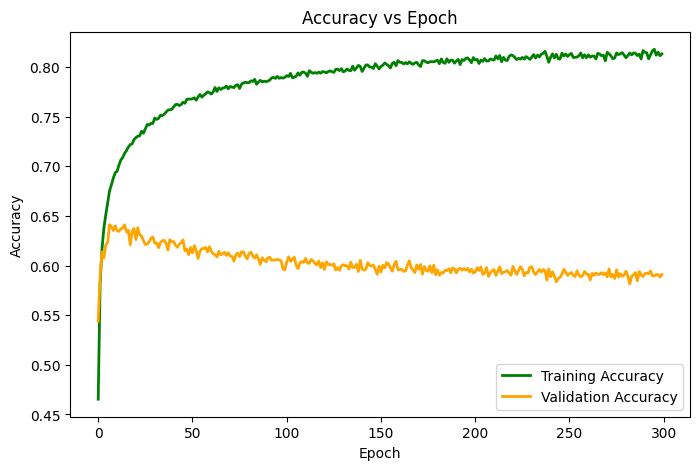

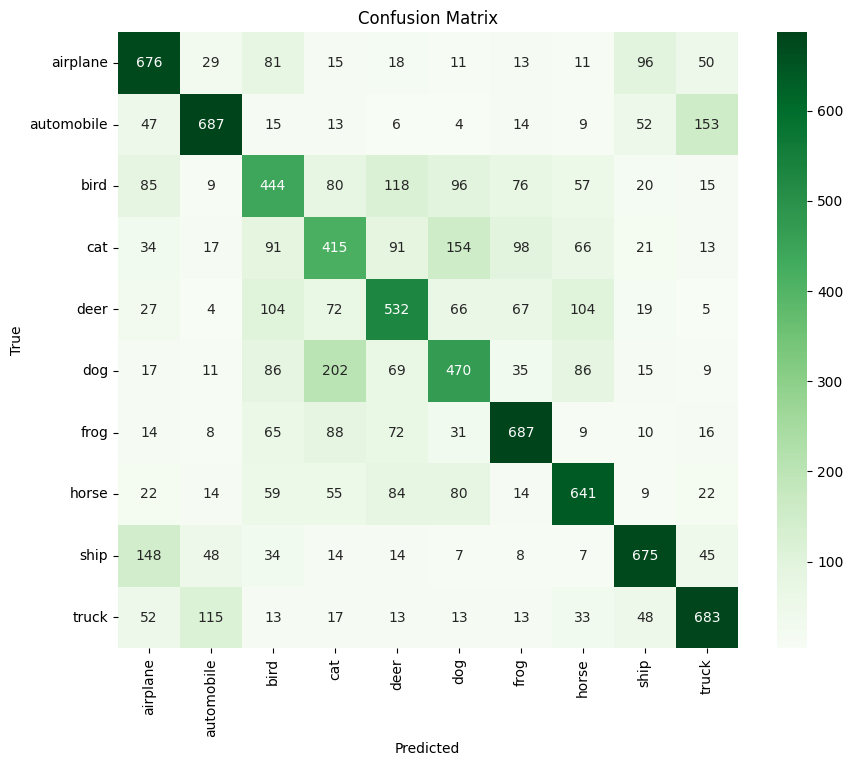

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010])
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2)

valset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform)
valloader = torch.utils.data.DataLoader(
    valset, batch_size=64, shuffle=False, num_workers=2)

classes = trainset.classes

# CNN model
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv block 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # Conv block 2
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        # Fully connected layers
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 10)  # 10 classes for CIFAR-10

    def forward(self, x):
        # First conv block: conv -> tanh -> maxpool
        x = F.max_pool2d(torch.tanh(self.conv1(x)), 2)   # (B, 16, 16, 16)
        # Second conv block
        x = F.max_pool2d(torch.tanh(self.conv2(x)), 2)   # (B, 8, 8, 8)
        # Flatten
        x = x.view(-1, 8 * 8 * 8)                        # (B, 512)
        # FC layers
        x = torch.tanh(self.fc1(x))                      # (B, 32)
        x = self.fc2(x)                                  # (B, 10)
        return x

net = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.0015)


# Storing data
train_losses = []
val_losses = []
train_accs = []
val_accs = []

num_epochs = 300
start_time = time.time()

# Training loop
for epoch in range(num_epochs):

    # Training
    net.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = net(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()

    avg_train_loss = running_loss / len(trainloader)
    train_acc = correct_train / total_train

    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # Validation
    net.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for x, y in valloader:
            x, y = x.to(device), y.to(device)

            outputs = net(x)
            loss = criterion(outputs, y)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += y.size(0)
            correct_val += (predicted == y).sum().item()

    avg_val_loss = running_val_loss / len(valloader)
    val_acc = correct_val / total_val

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch={epoch+1} "
          f"\nTraining Loss: {avg_train_loss:.4f}, Training Accuracy: {train_acc:.4f}"
          f"\nValidation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"\nTotal Training Time: {training_time:.2f} seconds\n")

# Model Size
def model_summary(model):
    print("\nModel Size\n")
    total_params = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:20} --> {num_params} parameters")
    print(f"Total Trainable Parameters: {total_params:,}")
    print("\n")

model_summary(net)
# Plot (losses)
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss", linewidth=2, color="Green")
plt.plot(val_losses, label="Validation Loss", linewidth=2, color="Orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# Plot (accuracies)
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Training Accuracy", linewidth=2, color="Green")
plt.plot(val_accs, label="Validation Accuracy", linewidth=2, color="Orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

# Confusion Matrix
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for x, y in valloader:
        x = x.to(device)
        outputs = net(x)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

**Problem-1(b)**

Device: cuda

Epoch=1 
Training Loss: 1.5759, Training Accuracy: 0.4295
Validation Loss: 1.3174, Validation Accuracy: 0.5270

Epoch=2 
Training Loss: 1.2596, Training Accuracy: 0.5519
Validation Loss: 1.2032, Validation Accuracy: 0.5713

Epoch=3 
Training Loss: 1.1639, Training Accuracy: 0.5880
Validation Loss: 1.1380, Validation Accuracy: 0.5957

Epoch=4 
Training Loss: 1.1040, Training Accuracy: 0.6095
Validation Loss: 1.1106, Validation Accuracy: 0.6068

Epoch=5 
Training Loss: 1.0663, Training Accuracy: 0.6260
Validation Loss: 1.0714, Validation Accuracy: 0.6277

Epoch=6 
Training Loss: 1.0357, Training Accuracy: 0.6341
Validation Loss: 1.0634, Validation Accuracy: 0.6270

Epoch=7 
Training Loss: 1.0134, Training Accuracy: 0.6428
Validation Loss: 1.0461, Validation Accuracy: 0.6311

Epoch=8 
Training Loss: 0.9934, Training Accuracy: 0.6514
Validation Loss: 1.0137, Validation Accuracy: 0.6437

Epoch=9 
Training Loss: 0.9775, Training Accuracy: 0.6571
Validation Loss: 1.0362, Validat

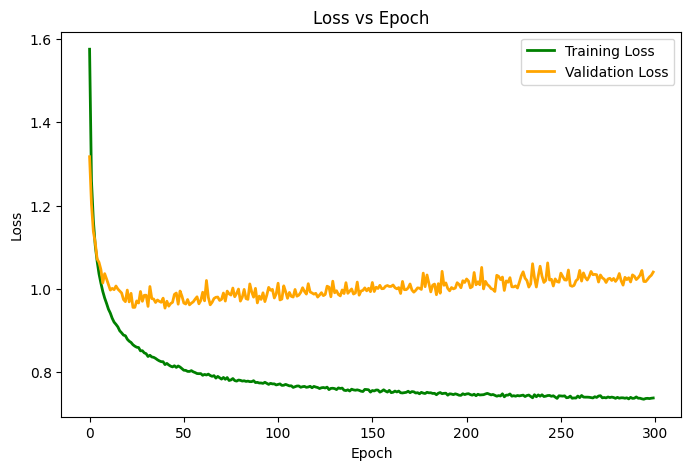

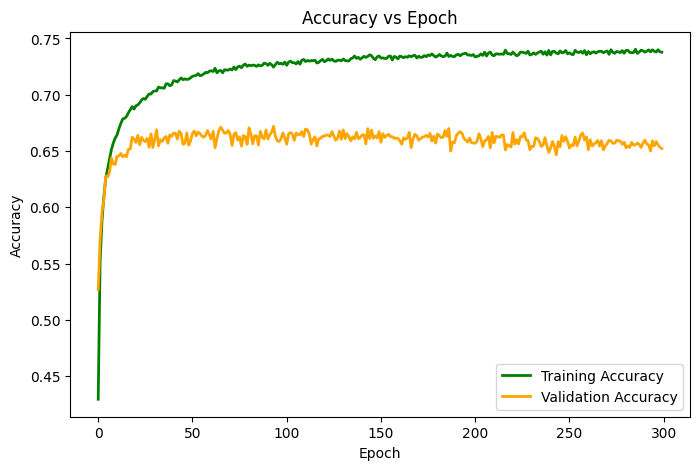

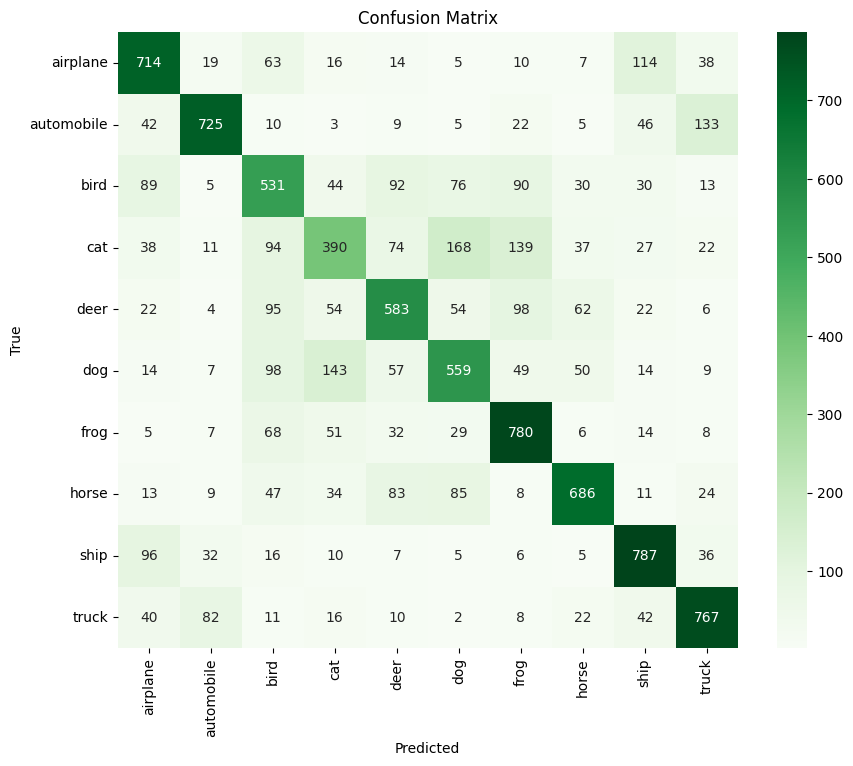

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010])
])

# Datasets and loaders
trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2)

valset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform)
valloader = torch.utils.data.DataLoader(
    valset, batch_size=64, shuffle=False, num_workers=2)

classes = trainset.classes

# CNN model with 3 conv blocks
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv block 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # Conv block 2
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        # Conv block 3 (new)
        self.conv3 = nn.Conv2d(8, 8, kernel_size=3, padding=1)

        # Spatial sizes:
        # Input: 32x32
        # After pool1 -> 16x16
        # After pool2 ->  8x8
        # After pool3 ->  4x4
        # Channels after conv3 = 8 → features = 8 * 4 * 4 = 128

        # Fully connected layers
        self.fc1 = nn.Linear(8 * 4 * 4, 32)
        self.fc2 = nn.Linear(32, 10)  # 10 classes for CIFAR-10

    def forward(self, x):
        # First conv block: conv -> tanh -> maxpool
        x = F.max_pool2d(torch.tanh(self.conv1(x)), 2)   # (B, 16, 16, 16)
        # Second conv block
        x = F.max_pool2d(torch.tanh(self.conv2(x)), 2)   # (B, 8, 8, 8)
        # Third conv block
        x = F.max_pool2d(torch.tanh(self.conv3(x)), 2)   # (B, 8, 4, 4)

        # Flatten
        x = x.view(-1, 8 * 4 * 4)                        # (B, 128)

        # FC layers
        x = torch.tanh(self.fc1(x))                      # (B, 32)
        x = self.fc2(x)                                  # (B, 10)
        return x

net = Net().to(device)

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.0015)

# Storing data
train_losses = []
val_losses = []
train_accs = []
val_accs = []

num_epochs = 300
start_time = time.time()

# Training loop
for epoch in range(num_epochs):

    # Training
    net.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = net(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()

    avg_train_loss = running_loss / len(trainloader)
    train_acc = correct_train / total_train

    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # Validation
    net.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for x, y in valloader:
            x, y = x.to(device), y.to(device)

            outputs = net(x)
            loss = criterion(outputs, y)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += y.size(0)
            correct_val += (predicted == y).sum().item()

    avg_val_loss = running_val_loss / len(valloader)
    val_acc = correct_val / total_val

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch={epoch+1} "
          f"\nTraining Loss: {avg_train_loss:.4f}, Training Accuracy: {train_acc:.4f}"
          f"\nValidation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"\nTotal Training Time: {training_time:.2f} seconds\n")

# Model Size
def model_summary(model):
    print("\nModel Size\n")
    total_params = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:20} --> {num_params} parameters")
    print(f"Total Trainable Parameters: {total_params:,}")
    print("\n")

model_summary(net)

# Plot (losses)
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss", linewidth=2, color="Green")
plt.plot(val_losses, label="Validation Loss", linewidth=2, color="Orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# Plot (accuracies)
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Training Accuracy", linewidth=2, color="Green")
plt.plot(val_accs, label="Validation Accuracy", linewidth=2, color="Orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

# Confusion Matrix
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for x, y in valloader:
        x = x.to(device)
        outputs = net(x)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
